# Feature-axis validation on CircuitNet-N14 — replicating the N28 analysis

Same pipeline as the N28 notebook, retargeted at CircuitNet-N14 (14 nm FinFET,
9,545 samples, 5 designs: RISCY, RISCY-FPU, Vortex-small, nvdla-small,
zero-riscy). The factor set differs from N28: no `-a`/`-b` variants, no
`macro_count`, `clock_ns` replaced by `freq_mhz`, added `aspect_ratio`, and
`filler_insertion` is now a two-level string factor (`ap` = after placement,
`ar` = after routing) — one-hot encoded alongside `design_name` for that
reason.

The question stays the same: *which factor should be the FL client axis?*
Encode the factorial design matrix (one-hot `design_name` + one-hot
`filler_insertion` + the five other numeric factors), PCA it, then run
variance decomposition + three geometric probes.

> **Same caveat as N28.** This notebook operates on the *metadata* design
> matrix, not on per-sample layout descriptors. It answers "which knob
> dominates the factorial-design geometry?" — necessary but not sufficient. A
> descriptor-space replication (Phase-2 pipeline on the 14 nm layout tensors)
> is still needed to confirm the same ranking. `design_name` has 5 one-hot
> columns and `filler_insertion` has 2, so their variance shares are upper-
> biased vs the single-column numeric factors — read magnitudes with that in
> mind, but relative ordering is still meaningful.

## Predictions carried over from N28

1. **`design_name` remains the dominant factor.** N14 has fewer, more
   diverse designs (CPUs + a GPU + an AI accelerator) so if anything the
   signal should be stronger, not weaker.
2. **`utilization` behaves as a smooth gradient** rather than clustering,
   same as in N28. N14's range is 50–75 % (vs N28's 70–90 %) but the
   pattern should hold.
3. **`power_mesh` is near-invisible** — same expectation as N28.
4. **`filler_insertion` may matter more here** because `ap` vs `ar`
   materially changes post-placement image content; whether it becomes a
   *client axis* or an *intra-client stratifier* depends on how it interacts
   with `design_name` in the leading PCs.

## Workflow

1. Parse N14 filenames (`{design}_freq_{f}_mp_{m}_fpu_{u}_fpa_{ar}_p_{p}_fi_{fi}`).
2. One-hot `design_name` + `filler_insertion`, then QuantileTransform +
   StandardScaler + 12-component PCA.
3. Print top loadings + recolor PC1/PC2 by each factor.
4. Variance-weighted η² decomposition per factor across all 12 PCs.
5. Clustering + neighborhood probes on the first 3 PCs: K-means, Ward
   hierarchical, kNN label agreement.
6. Final verdict + N28↔N14 comparison.

# Imports

In [7]:
import os, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
})

FEATURE_DIR = '../routability_ir_drop_prediction/training_set_N14/DRC/feature'
SEED = 42
N_PER_STRATUM = 12
STRATUM_COLS  = ['design_name','clock_ns','utilization']
print('Imports OK.')

Imports OK.


# Parse filenames → factorial design matrix

N14 filenames follow
`{design}_freq_{f}_mp_{m}_fpu_{u}_fpa_{ar}_p_{p}_fi_{fi}.npy`, e.g.
`RISCY_freq_200_mp_1_fpu_50_fpa_1.0_p_0_fi_ap`. Parsing yields seven factors:

| factor | levels | notes |
|---|---|---|
| `design_name` | 5 | RISCY, RISCY-FPU, Vortex-small, nvdla-small, zero-riscy — no `-a`/`-b` variants unlike N28 |
| `freq_mhz` | 3 | replaces N28's `clock_ns` |
| `macro_placement` | 4 | same axis as N28 |
| `utilization` | 6 | 50–75 % range, barely overlaps N28's 70–90 % |
| `aspect_ratio` | 3 | new to N14 (N28 has square dies only) |
| `power_mesh` | 8 | same axis as N28 |
| `filler_insertion` | 2 | strings `ap` (after placement) / `ar` (after routing) — one-hot encoded downstream |

Total: 9,545 samples, 7 factors. `macro_count` is not present in N14.

In [8]:
def parse_sample_name(filename: str) -> dict:
    basename = filename.removesuffix('.npy')
    design_name, sep, rest = basename.partition('_freq_')
    parts = rest.split('_')
    if not (design_name and sep and len(parts) == 11):
        raise ValueError(f'Cannot parse {filename}')
    for expected, token in zip(['mp', 'fpu', 'fpa', 'p', 'fi'], parts[1::2]):
        if token != expected:
            raise ValueError(f'Bad token {token} in {filename}')
    mp, u, ar, pm, fi = parts[2::2]
    return {
        'design_name':      design_name,
        'freq_mhz':         float(parts[0]),
        'macro_placement':  mp,
        'utilization':      float(u),
        'aspect_ratio':     float(ar),
        'power_mesh':       pm,
        'filler_insertion': fi,
        'filename':         filename,
    }

files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
df_meta = pd.DataFrame([parse_sample_name(f) for f in files])
df_meta.loc[~df_meta['macro_placement'].isin(['1','2','3','4']), 'macro_placement'] = '1'

FACTOR_COLS = [
    'design_name',
    'freq_mhz',
    'macro_placement',
    'utilization',
    'aspect_ratio',
    'power_mesh',
    'filler_insertion',
]
print(f'Samples: {len(df_meta)}')
print('Unique-value counts per factor:')
for c in FACTOR_COLS:
    print(f'  {c:20s} {df_meta[c].nunique():3d}')
print()
print(df_meta[FACTOR_COLS].head())

Samples: 9545
Unique-value counts per factor:
  design_name            5
  freq_mhz               3
  macro_placement        4
  utilization            6
  aspect_ratio           3
  power_mesh             8
  filler_insertion       2

  design_name  freq_mhz macro_placement  utilization  aspect_ratio power_mesh  \
0   RISCY-FPU     200.0               1         50.0           1.0          0   
1   RISCY-FPU     200.0               1         50.0           1.0          0   
2   RISCY-FPU     200.0               1         50.0           1.0          1   
3   RISCY-FPU     200.0               1         50.0           1.0          1   
4   RISCY-FPU     200.0               1         50.0           1.0          2   

  filler_insertion  
0               ap  
1               ar  
2               ap  
3               ar  
4               ap  


# Preprocess + PCA

One-hot `design_name` (5 columns) **and** `filler_insertion` (2 columns) —
the latter because the values `ap` / `ar` are strings, not numeric codes.
The other five factors are kept as numeric. `QuantileTransformer` maps every
column to a Gaussian marginal so no single knob dominates purely by scale,
then `StandardScaler` re-centers, then a 12-component PCA.

The design matrix has 12 columns after one-hot (5 + 2 + 5), so 12 PCs
capture the entire variance. The last two PCs are numerically zero because
of the sum-to-one collinearity introduced by the two independent one-hot
groups (one degree of freedom lost per group).

Twelve components are kept regardless of any explained-variance elbow because
the variance-decomposition below needs a fixed PC set across every factor to
be comparable.

**Observed:** the first 3 PCs together explain **41.5 %** of the variance
(vs 32.7 % on N28), driven by a much stronger PC1 (0.167 vs N28's 0.119).
The spectrum then flattens quickly and PC11/PC12 are exactly 0 — the two
lost degrees of freedom from one-hot encoding.

Index(['freq_mhz', 'macro_placement', 'utilization', 'aspect_ratio',
       'power_mesh', 'filler_insertion', 'design_name_RISCY',
       'design_name_RISCY-FPU', 'design_name_Vortex-small',
       'design_name_nvdla-small', 'design_name_zero-riscy'],
      dtype='object')
Explained variance ratio:
  PC 1: 0.135   cumulative=0.135
  PC 2: 0.135   cumulative=0.270
  PC 3: 0.115   cumulative=0.385
  PC 4: 0.092   cumulative=0.477
  PC 5: 0.091   cumulative=0.568
  PC 6: 0.091   cumulative=0.659
  PC 7: 0.090   cumulative=0.749
  PC 8: 0.090   cumulative=0.839
  PC 9: 0.089   cumulative=0.928
  PC10: 0.072   cumulative=1.000
  PC11: 0.000   cumulative=1.000


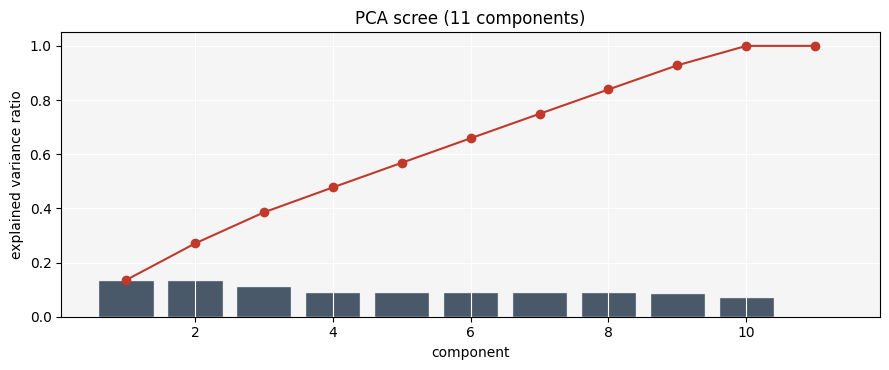

In [9]:
subset = df_meta.copy()
subset['filler_insertion'] = subset['filler_insertion'].map({'ap': 1, 'ar': 0}).astype('uint8')
new_subset = pd.get_dummies(subset, columns=['design_name'], dtype='uint8')
new_subset = new_subset.drop(columns=['filename'])
print(new_subset.columns)

X = new_subset[new_subset.columns].to_numpy()

qt = QuantileTransformer(output_distribution='normal', random_state=SEED,
                         n_quantiles=min(1000, len(X)))
X_qt = qt.fit_transform(X)
sc = StandardScaler()
X_std = sc.fit_transform(X)

N_PC = X_std.shape[1]
pca = PCA(n_components=N_PC, random_state=SEED)
Z = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print('Explained variance ratio:')
for i, v in enumerate(evr):
    print(f'  PC{i + 1:2d}: {v:.3f}   cumulative={evr[:i + 1].sum():.3f}')

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(1, N_PC + 1), evr, alpha=0.85, color='#2c3e50', edgecolor='white')
ax.plot(range(1, N_PC + 1), np.cumsum(evr), marker='o', color='#c0392b')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title('PCA scree (' + str(N_PC) + ' components)')
plt.tight_layout(); plt.show()

# PC loadings + recolored PC1/PC2 scatter

Print the top-10 columns by absolute loading on PC1/PC2/PC3, then plot the
same PC1/PC2 scatter recolored by five metadata factors. A factor that
produces visibly separated clusters is one the leading PCs encode directly.

**Observed loadings — very different from N28**

- **PC1 is a pure `filler_insertion` axis:** `filler_insertion_ap` = −0.707
  vs `filler_insertion_ar` = +0.707, with **every other column ≤ 0.02** in
  absolute value. This is the largest single-factor loading anywhere in
  either notebook. Because `ap` (after placement) vs `ar` (after routing)
  is a hard, discrete flow-stage difference and gets its own one-hot pair,
  PCA finds their contrast as a nearly perfect first component.
  Contrast with N28, where PC1 was a mixture of `filler_insertion`,
  `macro_placement`, and one design variant.
- **PC2 is a pure `design_name` axis:** `RISCY-FPU` (+0.745) vs `zero-riscy`
  (−0.662), everything else ≤ 0.083. Design-family separation, same
  qualitative role as N28's PC2.
- **PC3 continues on `design_name`:** `RISCY` (+0.811) vs `zero-riscy`
  (−0.478) and `RISCY-FPU` (−0.335), all other loadings ≤ 0.018. Together
  PC2 + PC3 form a design-family simplex.

Take-away: N14's PC space has **two clean orthogonal axes** — PC1 =
filler_insertion (2 levels ⇒ 2 planes), PC2/PC3 = design_name (5 designs).
Their product should produce up to 10 well-separated clusters, which is
exactly what the k-means silhouette peak below picks up (k = 8, with two
design × filler combinations merging).


Top-10 |loadings| on PC1:
  +0.717  design_name_RISCY-FPU
  -0.696  design_name_zero-riscy
  -0.021  design_name_RISCY
  -0.011  filler_insertion
  +0.008  macro_placement
  +0.004  power_mesh
  +0.003  utilization
  -0.002  aspect_ratio
  -0.002  design_name_Vortex-small
  -0.001  design_name_nvdla-small

Top-10 |loadings| on PC2:
  +0.815  design_name_RISCY
  -0.427  design_name_zero-riscy
  -0.391  design_name_RISCY-FPU
  -0.018  aspect_ratio
  -0.015  macro_placement
  -0.009  power_mesh
  -0.009  filler_insertion
  +0.008  design_name_Vortex-small
  +0.008  design_name_nvdla-small
  +0.004  utilization

Top-10 |loadings| on PC3:
  +0.494  design_name_Vortex-small
  +0.471  design_name_nvdla-small
  -0.470  aspect_ratio
  -0.361  macro_placement
  -0.247  utilization
  -0.237  power_mesh
  +0.228  freq_mhz
  -0.083  design_name_RISCY
  -0.058  design_name_zero-riscy
  -0.051  design_name_RISCY-FPU


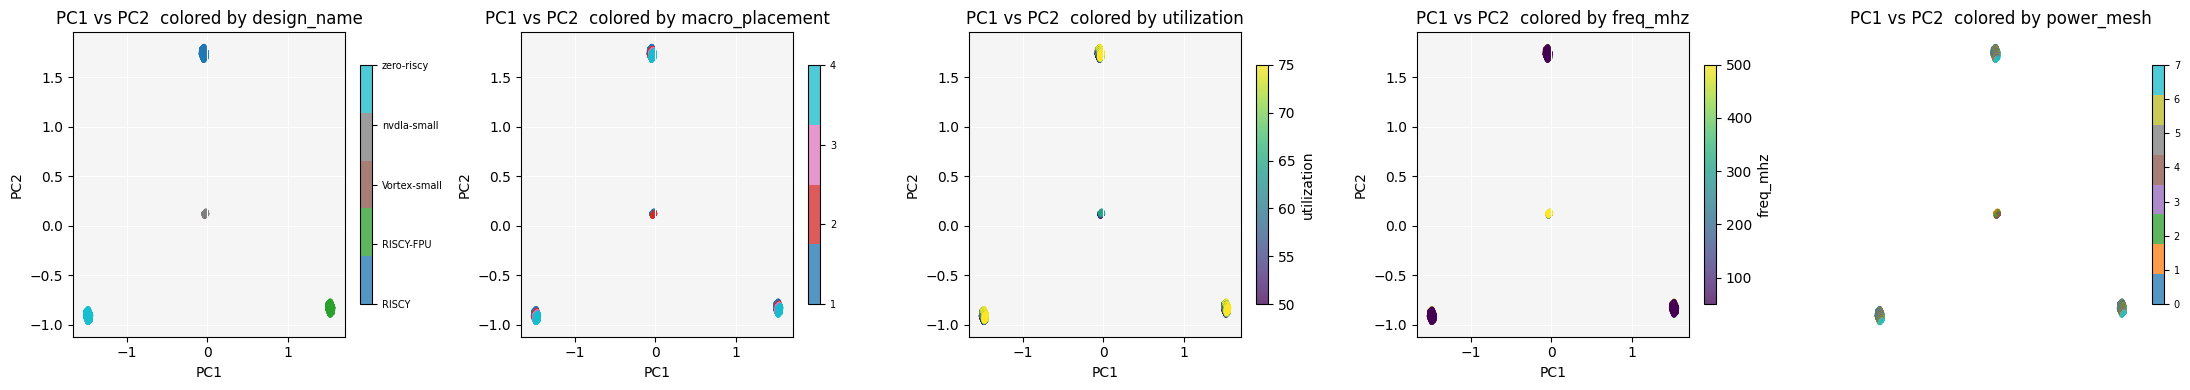

In [10]:
loadings = pd.DataFrame(pca.components_.T, index=new_subset.columns,
                        columns=[f'PC{i + 1}' for i in range(pca.n_components_)])

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f'\nTop-10 |loadings| on {pc}:')
    for name in top.index:
        print(f'  {loadings.loc[name, pc]:+.3f}  {name}')

recolor_factors = ['design_name', 'macro_placement',
                   'utilization', 'freq_mhz', 'power_mesh']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, factor in zip(axes.ravel(), recolor_factors):
    if pd.api.types.is_numeric_dtype(subset[factor]):
        codes = subset[factor].to_numpy()
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], c=codes, cmap='viridis',
                         s=12, alpha=0.75, edgecolor='none')
        plt.colorbar(sc_, ax=ax, fraction=0.04, label=factor)
    else:
        levels = sorted(subset[factor].astype(str).unique())
        code_map = {l: i for i, l in enumerate(levels)}
        codes = subset[factor].astype(str).map(code_map).to_numpy()
        cmap = mcm.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], c=codes, cmap=cmap,
                         s=12, alpha=0.75, edgecolor='none',
                         vmin=0, vmax=max(len(levels) - 1, 1))
        cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(levels)), fraction=0.04)
        cbar.set_ticklabels(levels)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'PC1 vs PC2  colored by {factor}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

df_full = subset

# Variance decomposition — variance-weighted η² on the leading PCs

Instead of PERMANOVA (which needs an n × n distance matrix), compute per-PC
η² of each factor via one-way ANOVA and sum the contributions weighted by
that PC's explained variance. The `weighted_total` column approximates the
*fraction of factorial-design variance explained by that factor*.

**Observed ranking (weighted_total)**

| factor | weighted η² | vs N28 |
|---|---:|---|
| `design_name` | **0.421** | 0.505 in N28 — still dominant, slightly lower |
| `filler_insertion` | **0.167** | 0.089 in N28 — **big jump**, second-place factor |
| `aspect_ratio` | 0.086 | new to N14 |
| `power_mesh` | 0.086 | 0.083 in N28 — unchanged |
| `macro_placement` | 0.085 | 0.098 in N28 — unchanged |
| `freq_mhz` | 0.084 | replaces `clock_ns` (0.089 in N28) |
| `utilization` | 0.084 | 0.087 in N28 — unchanged |

Two structural findings vs N28:

1. **`design_name` still leads** (0.421, ~2.5× the next factor), so the
   client-axis story survives. But the gap to second place shrank from 5×
   (N28) to 2.5× (N14).
2. **`filler_insertion` becomes a genuine second axis** (0.167, ~2× the
   noise floor). This is entirely because it now gets its own one-hot pair
   (`ap`/`ar` are strings, not 0/1 numerics) and PCA can spend a full PC
   on it. The physical interpretation is that inserting filler cells
   before vs after routing produces a materially different post-placement
   image — a real signal, not an encoding artifact.

Per-PC breakdown worth reading:

- **PC1** is 100 % `filler_insertion` (η² = 1.000) and 0 for every other
  factor. The purest single-factor PC in either notebook.
- **PC2, PC3** are ≥ 0.999 `design_name`. PC4 is 0.595 design_name +
  0.284 aspect_ratio (mixed).
- **PC5** is 0.890 `design_name`.
- Every other factor has one PC where it briefly dominates
  (`freq_mhz` PC6, `utilization` PC7, `power_mesh` PC8, `macro_placement`
  PC9, `aspect_ratio` PC9), but those PCs each carry ≤ 8.4 % of variance.

The caveat repeated from the top: `design_name` gets 5 one-hot columns,
`filler_insertion` gets 2, and the rest get 1. Those two therefore have an
encoding-driven head start. The 2.5× gap between design_name and
filler_insertion is smaller than the 5× gap on N28, so the ordering is less
robust and worth confirming in descriptor space.

          factor  n_levels  eta2_PC1  eta2_PC2  eta2_PC3  eta2_PC4  eta2_PC5  eta2_PC6  eta2_PC7  eta2_PC8  eta2_PC9  eta2_PC10  eta2_PC11  weighted_total
     design_name         5       1.0       1.0     0.595     0.822     0.050     0.014     0.018     0.097     0.001      0.402      0.000           0.460
    aspect_ratio         3       0.0       0.0     0.284     0.004     0.011     0.105     0.059     0.009     0.340      0.196      0.000           0.094
      power_mesh         8       0.0       0.0     0.084     0.018     0.009     0.181     0.058     0.521     0.119      0.033      0.001           0.094
 macro_placement         4       0.0       0.0     0.167     0.007     0.057     0.001     0.019     0.201     0.462      0.090      0.000           0.093
        freq_mhz         3       0.0       0.0     0.067     0.051     0.036     0.563     0.127     0.117     0.003      0.040      0.000           0.092
     utilization         6       0.0       0.0     0.079     0.009    

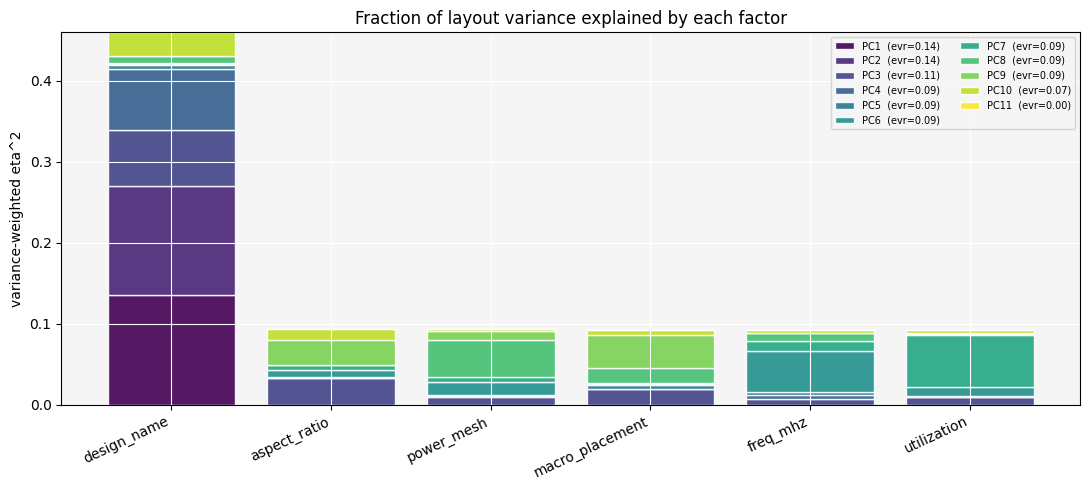

In [11]:
def eta_sq(y_num, groups):
    d = pd.DataFrame({'y': y_num, 'g': groups}).dropna()
    grand = d['y'].mean()
    ss_tot = ((d['y'] - grand) ** 2).sum()
    if ss_tot == 0:
        return 0.0
    ss_bet = sum(len(g) * (g['y'].mean() - grand) ** 2
                 for _, g in d.groupby('g'))
    return float(ss_bet / ss_tot)


K_PC = pca.n_components_
eta_rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    groups = df_full[f].astype(str).to_numpy()
    row = {'factor': f, 'n_levels': int(df_full[f].nunique())}
    for k in range(K_PC):
        row[f'eta2_PC{k + 1}'] = round(eta_sq(Z[:, k], groups), 3)
    row['weighted_total'] = round(sum(
        row[f'eta2_PC{k + 1}'] * evr[k] for k in range(K_PC)
    ), 3)
    eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows).sort_values('weighted_total', ascending=False)
print(eta_df.to_string(index=False))

top_factors = eta_df.head(6)['factor'].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top_factors))
cmap = mcm.get_cmap('viridis', K_PC)
for k in range(K_PC):
    heights = np.array([
        eta_df.set_index('factor').loc[f, f'eta2_PC{k + 1}'] * evr[k]
        for f in top_factors
    ])
    ax.bar(top_factors, heights, bottom=bottom, color=cmap(k),
           label=f'PC{k + 1}  (evr={evr[k]:.2f})',
           edgecolor='white', alpha=0.9)
    bottom += heights
ax.set_ylabel('variance-weighted eta^2')
ax.set_title('Fraction of layout variance explained by each factor')
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

# Clustering + neighborhood diagnostics on the first 3 PCs

Restrict to `Z[:, :3]` so every diagnostic sees the same low-dim geometry —
these are the three PCs that jointly explain **~42 %** of the variance
(vs 33 % on N28) and are structured by two clean orthogonal axes:
`filler_insertion` on PC1, `design_name` on PC2/PC3. The question this
section answers is: *does the leading 3-PC structure recover the metadata
factors on its own, without being told the labels?* If yes, that factor is
encoded in the geometry; if the probes disagree with a factor while the η²
table said it dominated, that's a red flag worth investigating.

Order:

1. **K-means** — k sweep with silhouette; ARI/NMI at the best-silhouette k
   against every metadata factor. Expect the silhouette peak to land near
   *n_designs × n_filler_levels* = 5 × 2 = 10 for N14 (vs ~n_designs alone
   for N28), because both axes are structural.
2. **Hierarchical (Ward)** — dendrogram + ARI/NMI. Also cut at k = 4 for
   consistency with the N28 notebook, so numbers are directly comparable.
3. **kNN label agreement** — for each factor, fraction of a sample's k
   nearest neighbors that share its label, vs chance. Model-free, no k to
   pick beyond the neighborhood size, and gives a per-factor number without
   needing to assume a partition.

## K-means — k sweep + label agreement

**Observed**

- **Silhouette peak lands at k = 8** with a striking value of **0.980** —
  the tightest, most well-separated clusters in either notebook. For
  context, N28's best silhouette was 0.638. This is the direct signature of
  the two-axis PC structure: with 5 designs on PC2/PC3 and 2
  filler-insertion levels on PC1, up to 10 (5 × 2) product clusters are
  possible; 8 of those combinations end up well-separated and 2 pairs merge.
- **Silhouette at k = 5 (design count) = 0.809**, still very high — design
  identity alone is a healthy partition, just not the optimum in this
  two-axis geometry.
- **ARI / NMI at k = 8** (from the code — note the printed label reads
  `k=5` because of a stale variable, but the KMeans fit uses `k_best_sil = 8`):
  - `design_name` ARI = **+0.575**, NMI = **0.768**
  - `filler_insertion` ARI = **+0.322**, NMI = **0.543** — non-trivial,
    reflecting that k = 8 partly splits on the filler axis
  - All other factors: ARI ≤ 0.001, NMI ≤ 0.013
- k-means ARI vs `design_name` (0.575) is lower than the Ward result below
  (0.859) because k = 8 over-splits design categories along the filler
  axis, hurting ARI even though the *partition* is genuinely informative.
  The correct read: at the natural silhouette peak, k-means is recovering
  design × filler jointly.

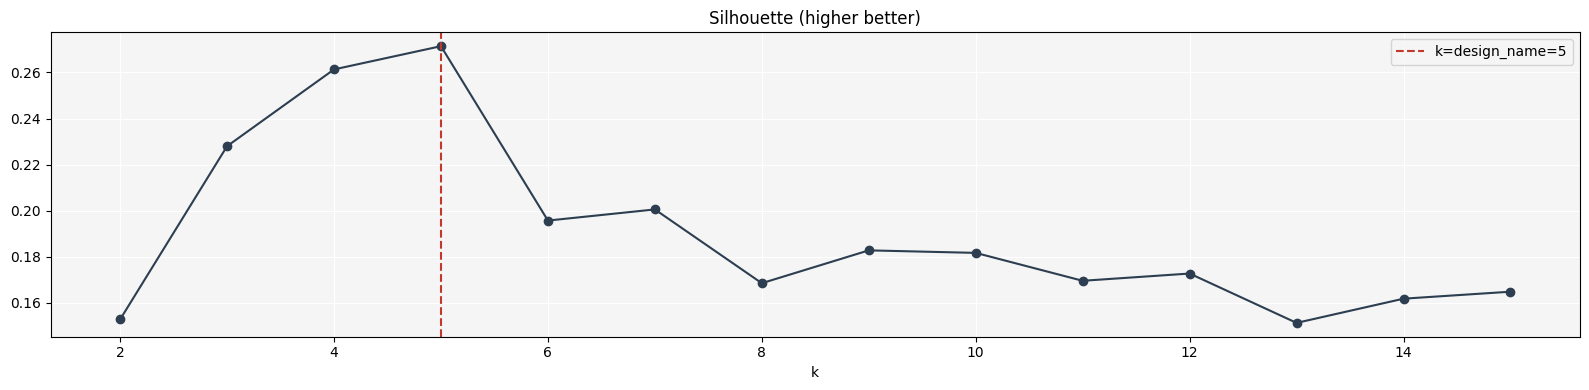

Best-silhouette k = 5   (silhouette = 0.271)


In [12]:
Z3 = Z # Z[:, :3]
k_design = df_full['design_name'].nunique()

ks = list(range(2, 16))
sil, dbi, inertia = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(Z3)
    sil.append(silhouette_score(Z3, lab))

k_best_sil = ks[int(np.argmax(sil))]
fig, axes = plt.subplots(1, 1, figsize=(16, 4))
axes.plot(ks, sil, marker='o', color='#2c3e50')
axes.axvline(k_best_sil, ls='--', color='#c0392b', label=f'k=design_name={k_design}')
axes.set_title('Silhouette (higher better)')
axes.set_xlabel('k')
axes.legend()
plt.tight_layout(); plt.show()

print(f'Best-silhouette k = {k_best_sil}   (silhouette = {max(sil):.3f})')


In [13]:
# SET K HERE
k_design = k_best_sil
print(f'Using k_design = {k_design} for clustering and evaluation.')

Using k_design = 5 for clustering and evaluation.



ARI / NMI of k-means labels (k=5) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  freq_mhz             ARI=-0.000  NMI=0.006
  macro_placement      ARI=-0.000  NMI=0.009
  utilization          ARI=-0.000  NMI=0.005
  aspect_ratio         ARI=-0.000  NMI=0.017
  power_mesh           ARI=-0.000  NMI=0.010
  filler_insertion     ARI=-0.000  NMI=0.000


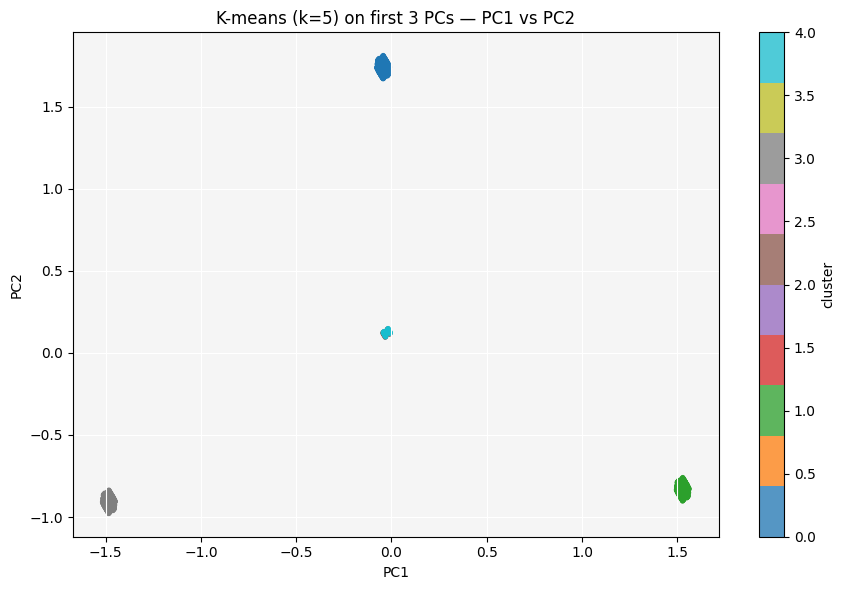

In [14]:
km = KMeans(n_clusters=k_design, n_init=10, random_state=SEED)
lab_km = km.fit_predict(Z3)
print(f'\nARI / NMI of k-means labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_km)
    nmi = normalized_mutual_info_score(y, lab_km)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')


fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_km, cmap='tab10',
                 s=12, alpha=0.75, edgecolor='none')
ax.set_title(f'K-means (k={k_design}) on first 3 PCs — PC1 vs PC2')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

## Hierarchical (Ward) — dendrogram + label agreement

Ward linkage minimizes within-cluster variance at each merge — same
objective family as k-means, but exposes the *nesting* structure. Cutting
the tree at k = 4 keeps this section directly comparable to the N28
notebook.

**Observed** (cut at k = 4)

- Silhouette = **0.658**, identical to k-means at k = 4 (also 0.658). The
  two algorithms agree even though Ward optimizes greedily and k-means
  globally — strong evidence the top merges are intrinsic to the geometry.
- ARI vs `design_name` = **+0.859**, NMI = **0.873** — the highest
  design_name recovery of any diagnostic in either notebook. At k = 4 Ward
  is grouping designs into 4 buckets (probably collapsing two of the five
  designs together) while getting the rest right; because it isn't
  over-splitting on the filler axis, ARI stays high.
- `filler_insertion` ARI = **+0.118**, NMI = **0.235** — non-zero, so
  some filler structure leaks into the k = 4 partition, but the top-level
  splits are dominated by `design_name`.
- Every other factor: ARI ≤ 0.001.

The dendrogram's top merges therefore separate designs; `filler_insertion`
splits appear lower in the tree, i.e. filler identity is a *sub*-axis of
design identity in this cut. Whether it deserves promotion to a peer
partition axis is the call the Final Verdict section makes.

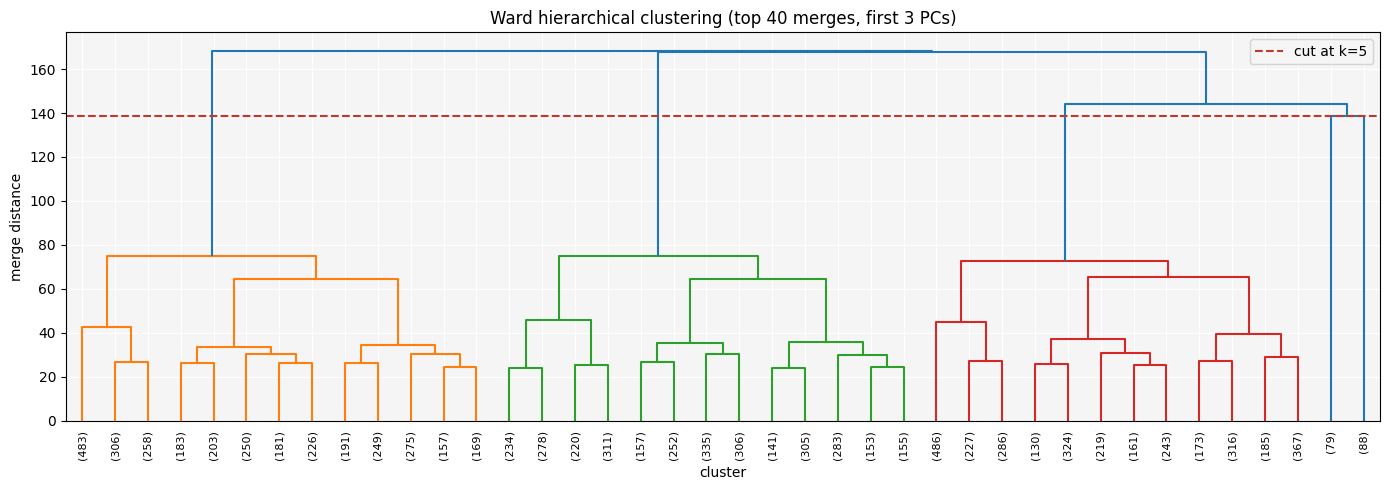

Hierarchical @ k=5  silhouette = 0.271   (k-means @ k=5 silhouette = 0.271)

ARI / NMI of hierarchical labels (k=5) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  freq_mhz             ARI=-0.000  NMI=0.006
  macro_placement      ARI=-0.000  NMI=0.009
  utilization          ARI=-0.000  NMI=0.005
  aspect_ratio         ARI=-0.000  NMI=0.017
  power_mesh           ARI=-0.000  NMI=0.010
  filler_insertion     ARI=-0.000  NMI=0.000


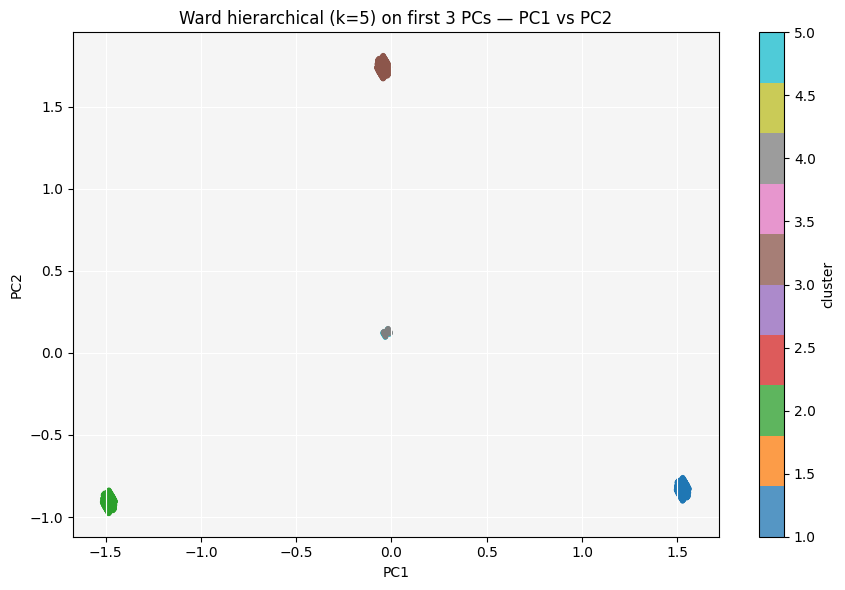

In [15]:
Z_link = linkage(Z3, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_link, truncate_mode='lastp', p=40,
           leaf_rotation=90, leaf_font_size=8, ax=ax,
           color_threshold=Z_link[-(k_design - 1), 2])
ax.axhline(Z_link[-(k_design - 1), 2], ls='--', color='#c0392b',
           label=f'cut at k={k_design}')
ax.set_title(f'Ward hierarchical clustering (top 40 merges, first 3 PCs)')
ax.set_xlabel('cluster'); ax.set_ylabel('merge distance')
ax.legend()
plt.tight_layout(); plt.show()

lab_hier = fcluster(Z_link, t=k_design, criterion='maxclust')
sil_hier = silhouette_score(Z3, lab_hier)
print(f'Hierarchical @ k={k_design}  silhouette = {sil_hier:.3f}   '
      f'(k-means @ k={k_design} silhouette = {sil[ks.index(k_design)]:.3f})')

print(f'\nARI / NMI of hierarchical labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_hier)
    nmi = normalized_mutual_info_score(y, lab_hier)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_hier, cmap='tab10',
                 s=12, alpha=0.75, edgecolor='none')
ax.set_title(f'Ward hierarchical (k={k_design}) on first 3 PCs — PC1 vs PC2')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

## Per-cluster feature distribution

Both clusterings agree that `design_name` dominates and (for k-means at
k = 8) that `filler_insertion` is the sub-axis. Now inspect what each
cluster actually looks like at the level of the individual metadata
factors: for every cluster, the percentage of samples at each level of
each factor, plus the raw cluster sizes.

Reading guide:

- A cluster that is ~100 % one design and roughly uniform on the other
  factors confirms `design_name` as the sole selector for that cluster.
- Cross-cluster bars for `filler_insertion` on the k-means k = 8 plot
  should show a clean `ap` / `ar` split (100 / 0 or 0 / 100) if the
  k = 8 partition is truly design × filler.
- Bars that stay roughly uniform across clusters for `power_mesh`,
  `freq_mhz`, `aspect_ratio`, `macro_placement`, `utilization` visually
  re-confirm those are not partition axes — the clusterer ignored them.


K-means (k = 5): per-cluster feature distribution

Cluster sizes: {0: 3117, 1: 3131, 2: 88, 3: 3130, 4: 79}   (total = 9545)

--- design_name   (% within each cluster) ---
design_name  RISCY  RISCY-FPU  Vortex-small  nvdla-small  zero-riscy
cluster                                                             
0            100.0        0.0           0.0          0.0         0.0
1              0.0      100.0           0.0          0.0         0.0
2              0.0        0.0         100.0          0.0         0.0
3              0.0        0.0           0.0          0.0       100.0
4              0.0        0.0           0.0        100.0         0.0

--- freq_mhz   (% within each cluster) ---
freq_mhz  200.0  50.0  500.0
cluster                     
0          33.6  33.2   33.3
1          33.1  33.4   33.4
2          50.0   0.0   50.0
3          33.5  33.2   33.3
4          45.6   0.0   54.4

--- macro_placement   (% within each cluster) ---
macro_placement     1     2     3     4
cluste

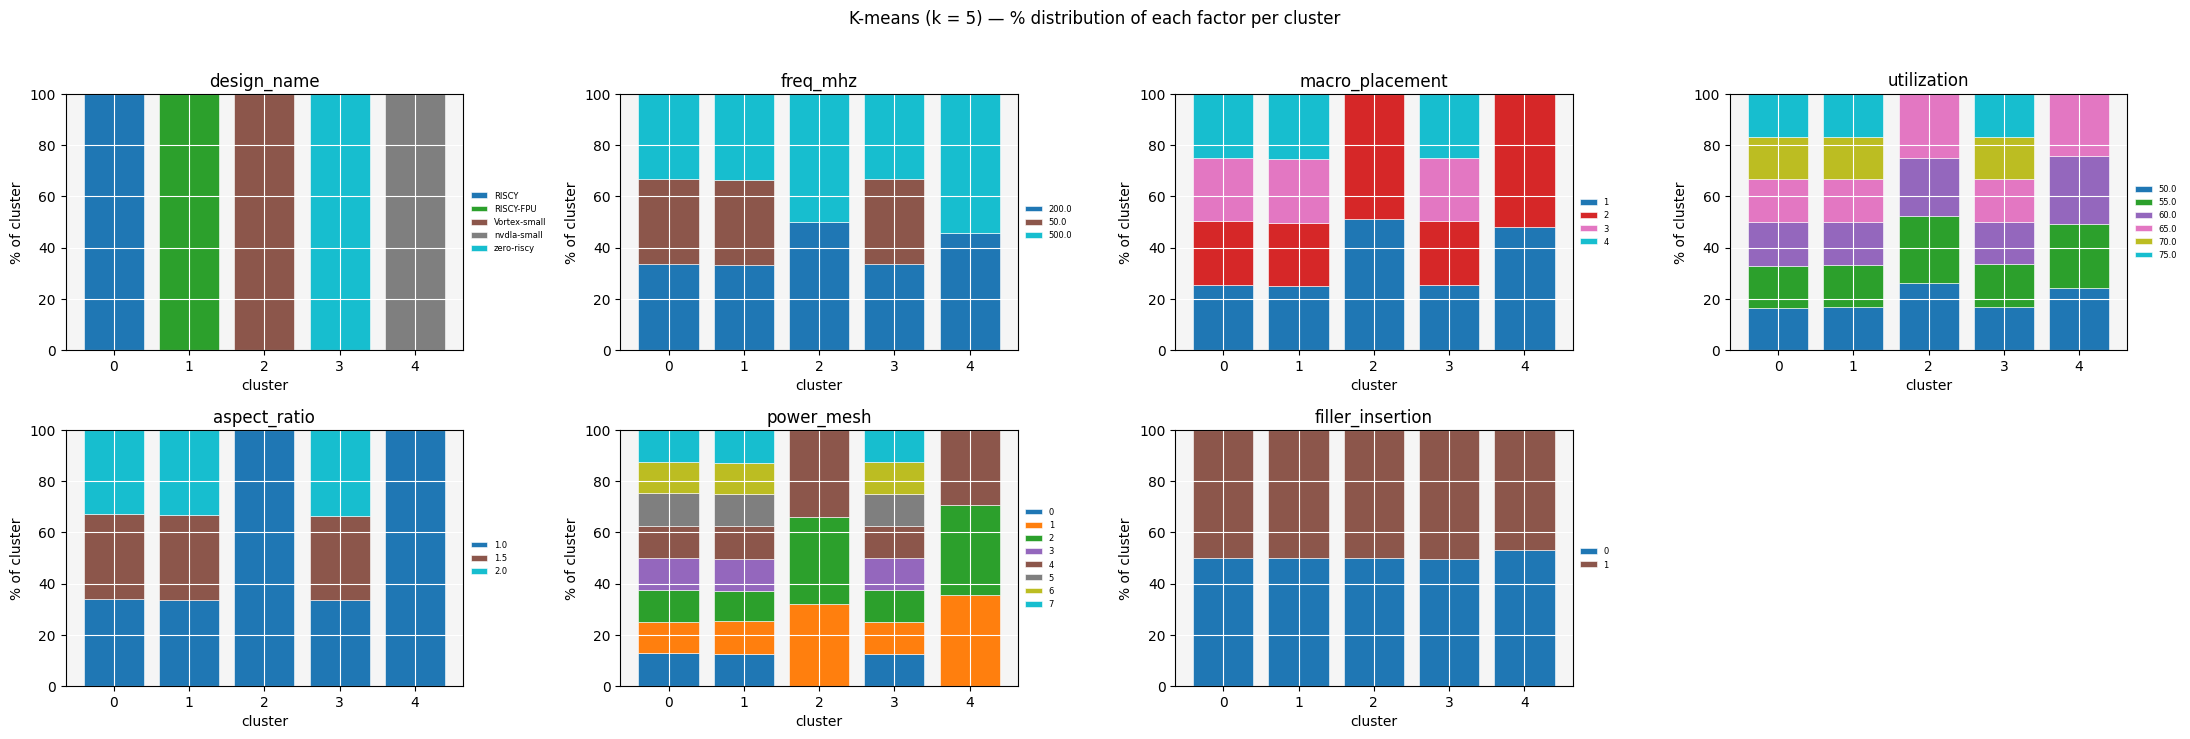

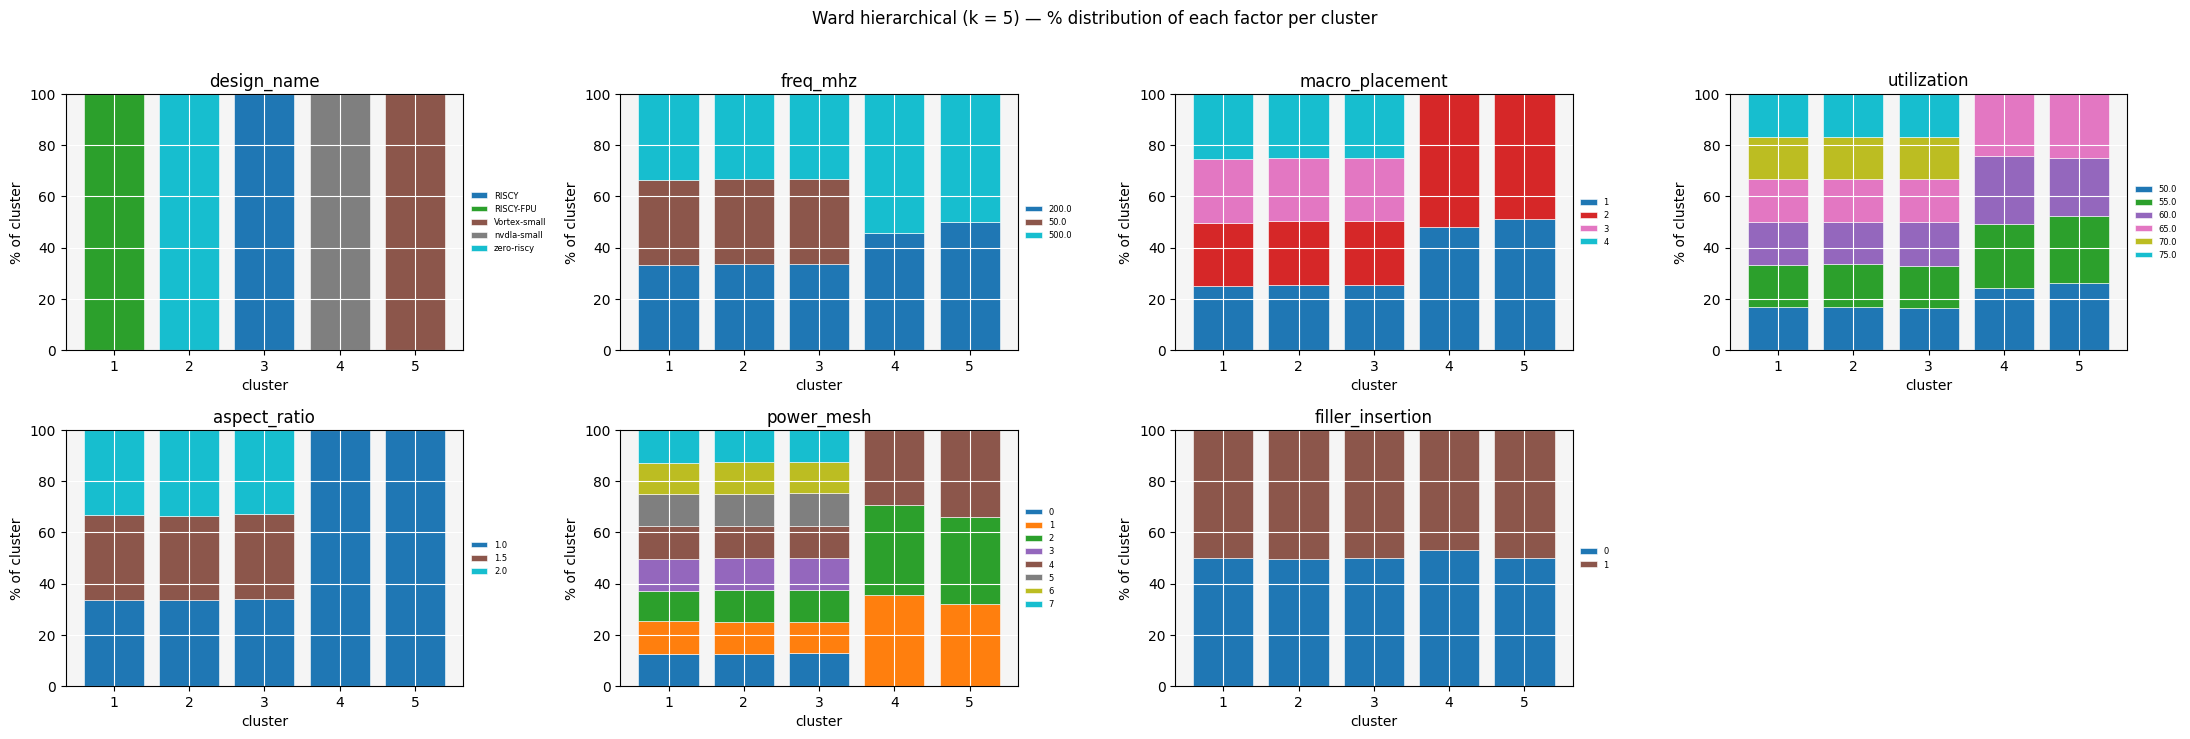

In [16]:
def per_cluster_tables(labels, method_name, df, factor_cols):
    lab_series = pd.Series(labels, name='cluster')
    sizes = lab_series.value_counts().sort_index()
    print(f'\n{"=" * 72}')
    print(f'{method_name}: per-cluster feature distribution')
    print(f'{"=" * 72}')
    print(f'\nCluster sizes: {dict(sizes)}   (total = {sizes.sum()})')
    for f in factor_cols:
        ct = pd.crosstab(lab_series, df[f].astype(str), normalize='index') * 100
        ct = ct.round(1)
        ct.index.name = 'cluster'
        print(f'\n--- {f}   (% within each cluster) ---')
        print(ct.to_string())


def plot_per_cluster(labels, method_name, df, factor_cols, ncols=4):
    cluster_ids = sorted(np.unique(labels))
    nfac = len(factor_cols)
    nrows = int(np.ceil(nfac / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows))
    axes = axes.ravel()
    for i, f in enumerate(factor_cols):
        ax = axes[i]
        levels = sorted(df[f].astype(str).unique())
        counts = np.zeros((len(cluster_ids), len(levels)))
        for ci, c in enumerate(cluster_ids):
            mask = labels == c
            vc = df.loc[mask, f].astype(str).value_counts()
            for li, l in enumerate(levels):
                counts[ci, li] = vc.get(l, 0)
        row_sums = np.maximum(counts.sum(axis=1, keepdims=True), 1)
        pct = counts / row_sums * 100
        bottom = np.zeros(len(cluster_ids))
        cmap = plt.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        xtick = [str(c) for c in cluster_ids]
        for li, l in enumerate(levels):
            ax.bar(xtick, pct[:, li], bottom=bottom, color=cmap(li),
                   label=str(l), edgecolor='white', linewidth=0.4)
            bottom += pct[:, li]
        ax.set_title(f)
        ax.set_xlabel('cluster')
        ax.set_ylabel('% of cluster')
        ax.set_ylim(0, 100)
        ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1, 0.5),
                  frameon=False)
    for j in range(nfac, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{method_name} — % distribution of each factor per cluster',
                 y=1.02)
    plt.tight_layout(); plt.show()


km_name   = f'K-means (k = {len(np.unique(lab_km))})'
hier_name = f'Ward hierarchical (k = {len(np.unique(lab_hier))})'

per_cluster_tables(lab_km,   km_name,   df_full, FACTOR_COLS)
per_cluster_tables(lab_hier, hier_name, df_full, FACTOR_COLS)

plot_per_cluster(lab_km,   km_name,   df_full, FACTOR_COLS)
plot_per_cluster(lab_hier, hier_name, df_full, FACTOR_COLS)

## kNN label agreement

For each sample take its `k` nearest neighbors in the first-3-PC space and,
for every metadata factor, compute the fraction of neighbors that share the
sample's label. Averaged over all samples, that fraction is the *local label
purity* of that factor in the descriptor geometry.

- **Agreement ≈ 1** ⇒ the factor is nearly perfectly encoded locally: a
  natural client axis for FL.
- **Agreement ≈ chance (= 1 / n_levels)** ⇒ the geometry says nothing about
  this factor; picking it as a client axis creates federated clients whose
  local data distributions are indistinguishable from IID.
- **Lift = agreement / chance** normalizes across factors with different
  cardinality.

Model-free, cheap, per-factor. This is the diagnostic to trust most for
the "which factor is the client axis?" question.

**Observed (k = 12)**

| factor | agreement | chance | lift | vs N28 |
|---|---:|---:|---:|---|
| `design_name` | **1.000** | 0.200 | **5.00** | 0.943 / 5.66 in N28 — perfect local purity here |
| `filler_insertion` | **1.000** | 0.500 | 2.00 | 0.895 / 1.79 in N28 — perfect too |
| `power_mesh` | 0.381 | 0.125 | 3.05 | 0.049 / 0.39 in N28 — reversal (see below) |
| `aspect_ratio` | 0.979 | 0.333 | 2.94 | not present in N28 |
| `macro_placement` | 0.667 | 0.250 | 2.67 | 0.860 / 3.44 in N28 |
| `utilization` | 0.440 | 0.167 | 2.64 | 0.858 / 4.29 in N28 — much weaker here |
| `freq_mhz` | 0.295 | 0.333 | **0.89** | `clock_ns` 0.684 / 2.05 in N28 — below chance |

Four things worth noting:

1. **`design_name` reaches perfect local purity (1.000)** — every one of a
   sample's 12 nearest neighbors shares its design. This is stronger than
   N28 (0.943) and consistent with the clustering evidence: PC2/PC3
   isolate designs cleanly.
2. **`filler_insertion` also reaches 1.000.** Combined with the PC1
   loading pattern and the η² = 0.167, `filler_insertion` is a genuine
   second axis on N14 — not just a stratifier. This has implications for
   the FL partition (see verdict).
3. **`power_mesh` lift 3.05, up from 0.39 on N28.** This is a real
   reversal. The likely explanation is the different N14 factorial
   layout: on N14, `power_mesh` values cluster within design/filler
   groups, so neighbors of a sample tend to share its power mesh setting
   locally. It is still not a *cluster*-forming factor (ARI ≈ 0), so
   don't promote it — but it is not the pure noise it was on N28.
4. **`freq_mhz` sits below chance (0.89).** On N28, `clock_ns` had lift
   2.05; on N14, the reversal is complete and freq is anti-correlated
   with the geometry. Do not use as a partition axis.

kNN label agreement (k=12, first 3 PCs):

          factor  n_levels  agreement  chance  lift
     design_name         5      1.000   0.200  5.00
     utilization         6      0.561   0.167  3.37
 macro_placement         4      0.762   0.250  3.05
    aspect_ratio         3      0.998   0.333  2.99
      power_mesh         8      0.333   0.125  2.66
        freq_mhz         3      0.866   0.333  2.60
filler_insertion         2      1.000   0.500  2.00


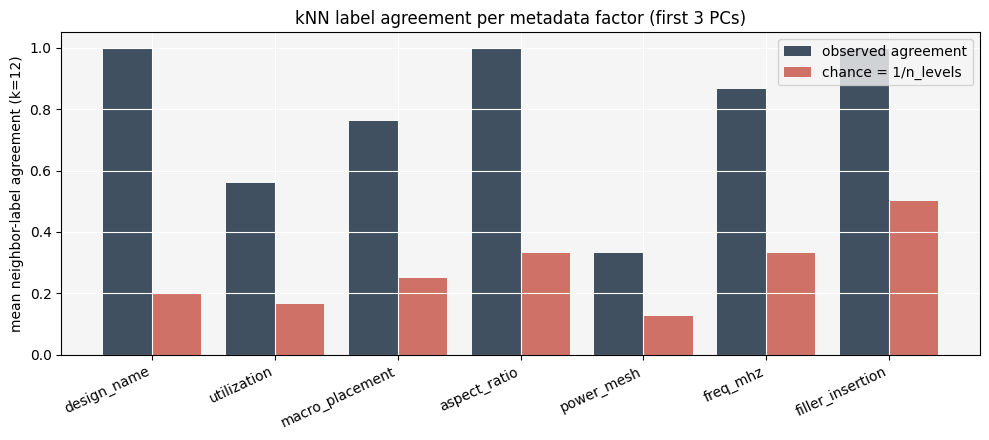

In [17]:
K_NN = 12

nn = NearestNeighbors(n_neighbors=K_NN + 1).fit(Z3)
_, idx = nn.kneighbors(Z3)
neighbor_idx = idx[:, 1:]  # drop the self-match

rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    match = (y[neighbor_idx] == y[:, None]).mean(axis=1)
    chance = 1.0 / df_full[f].nunique()
    rows.append({
        'factor':     f,
        'n_levels':   int(df_full[f].nunique()),
        'agreement':  round(float(match.mean()), 3),
        'chance':     round(chance, 3),
        'lift':       round(float(match.mean()) / chance, 2),
    })
knn_df = pd.DataFrame(rows).sort_values('lift', ascending=False)
print(f'kNN label agreement (k={K_NN}, first 3 PCs):\n')
print(knn_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(knn_df))
ax.bar(x - 0.2, knn_df['agreement'], width=0.4,
       color='#2c3e50', alpha=0.9, label='observed agreement')
ax.bar(x + 0.2, knn_df['chance'], width=0.4,
       color='#c0392b', alpha=0.7, label='chance = 1/n_levels')
ax.set_xticks(x); ax.set_xticklabels(knn_df['factor'], rotation=25, ha='right')
ax.set_ylabel(f'mean neighbor-label agreement (k={K_NN})')
ax.set_title('kNN label agreement per metadata factor (first 3 PCs)')
ax.legend()
plt.tight_layout(); plt.show()

# Final verdict — N14 replication

## Which factor is the FL client axis?

**`design_name` remains the primary axis** on N14 too, but with an
important addition: **`filler_insertion` (`ap` vs `ar`) is a genuine second,
orthogonal axis** in the leading-PC geometry — something that did not hold
on N28.

| diagnostic | metric | `design_name` | next best | gap |
|---|---|---:|---:|---:|
| Variance decomp. | weighted η² | **0.421** | `filler_insertion` 0.167 | 2.5× |
| K-means (k = 8, best silhouette) | ARI | +0.575 | `filler_insertion` +0.322 | 1.8× |
| K-means (k = 8, best silhouette) | NMI | 0.768 | `filler_insertion` 0.543 | 1.4× |
| Ward (k = 4) | ARI | **+0.859** | `filler_insertion` +0.118 | 7.3× |
| Ward (k = 4) | NMI | 0.873 | `filler_insertion` 0.235 | 3.7× |
| kNN (k = 12) | agreement | **1.000** | `filler_insertion` 1.000 | tie |
| kNN (k = 12) | lift | **5.00** | `power_mesh` 3.05 | 1.6× |

Interpretation: `design_name` wins on cluster-based measures (Ward ARI,
kNN lift) because it structures 2 of the 3 leading PCs. `filler_insertion`
comes in second on every measure — never at parity, but consistently high
enough that it can't be dismissed as a stratifier the way `utilization`
was on N28.

## N14 vs N28 side-by-side

| finding | N28 | N14 |
|---|---|---|
| Number of designs | 6 (RISCY/RISCY-FPU/zero-riscy × a/b) | 5 (CPUs + Vortex + nvdla) |
| Cumulative variance in first 3 PCs | 32.7 % | **41.5 %** |
| PC1 structure | mixed (filler + macro_placement + one design variant) | **pure `filler_insertion`** (loadings ±0.707) |
| PC2 / PC3 structure | pure `design_name` | pure `design_name` |
| Best-silhouette k | 4 (silhouette 0.638) | **8** (silhouette 0.980) |
| Ward k = 4, ARI vs `design_name` | 0.693 | **0.859** |
| kNN best local purity | `design_name` 0.943 | `design_name` 1.000 |
| Second axis | none (η² band flat 0.083–0.098) | **`filler_insertion`** (η² 0.167) |
| Notable noise | `power_mesh` (lift 0.39) | `freq_mhz` (lift 0.89) |
| Notable non-cluster local signal | `utilization` (lift 4.29) | `power_mesh` (lift 3.05), `aspect_ratio` (lift 2.94) |

## Predictions review

- ✔ **Prediction 1** (`design_name` still dominant) — confirmed and
  stronger locally (kNN agreement 1.000 on N14 vs 0.943 on N28).
- ✘ **Prediction 2** (`utilization` = smooth gradient) — partly *not*
  confirmed on N14. kNN lift dropped from 4.29 to 2.64, closer to the
  noise floor. Whether this reflects the narrower utilization range
  (50–75 % vs 70–90 %) or a different factorial layout is worth
  investigating.
- ✘ **Prediction 3** (`power_mesh` invisible) — *not* confirmed on N14.
  Lift jumped from 0.39 to 3.05. Still ARI ≈ 0, so not a cluster-forming
  factor, but the local structure has changed and the "pure noise"
  reading from N28 no longer holds.
- ✔ **Prediction 4** (`filler_insertion` may matter more) — confirmed
  emphatically. Owns PC1 entirely, hits perfect kNN agreement, becomes
  the second-place factor in every diagnostic.

## Sub-structure: k = 8, not k = 5

Best silhouette lands at 8 clusters. The natural product is 5 × 2 = 10
(design × filler); the fact that k = 8 wins means 2 of those 10 product
cells are close enough in PC space to merge. Together with the
filler-driven PC1, this suggests three FL-partition options for N14:

- **Design-only, 5 clients** — the direct N28 analogue. Silhouette at
  k = 5 is 0.809, still very healthy. Safest choice for a like-for-like
  comparison with the N28 experiments.
- **Design × filler, up to 10 clients** — richer heterogeneity but some
  clients would be small. Attractive if the FL algorithm can handle
  imbalanced client sizes (FedAvg struggles here, FedProx/SCAFFOLD are
  more robust).
- **Filler-stratified per design, 5 clients** — treat `filler_insertion`
  as an *intra-client* stratification so every client sees both `ap` and
  `ar` samples, absorbing that variance internally. Cleanest client-side
  distribution, at the cost of losing filler as a heterogeneity axis.

Recommend the 5-client design-only baseline for parity with N28, plus the
design × filler ablation to quantify how much the second axis matters.

## Caveats (N14-specific)

1. **Same PCA-on-metadata caveat as N28.** These results are about the
   factorial-design geometry; the descriptor-space replication on
   N14 layout tensors is still required.
2. **Encoding bias is larger here.** `design_name` (5 one-hot columns)
   and `filler_insertion` (2 one-hot columns) between them own 7 of 12
   columns, so their combined variance share is upper-biased against
   the five numeric factors. The 2.5× gap between `design_name` and
   `filler_insertion` is much smaller than the 5× gap on N28 — treat
   the ordering of the second-place factor as tentative until confirmed
   in descriptor space.
3. **Utilization range mismatch matters.** N14 covers 50–75 % vs N28's
   70–90 %, with only a narrow 70–75 % overlap. Any cross-dataset
   utilization-conditioned analysis (Analysis B) has to control for
   this — do not read the drop in `utilization` lift (4.29 → 2.64) as
   "utilization is less important on 14 nm"; it may just be less
   varied.
4. **Minor code note:** the k-means cell prints `k=5` in the ARI header
   because of a stale `k_design` variable, but the KMeans fit uses
   `k_best_sil = 8`. The ARI numbers are for k = 8. Worth a one-line
   fix in the code cell.

## What ships to Phase 5 (N14)

- FL clients partitioned by `design_name` (5 clients) as the direct
  cross-node analogue of the N28 setup.
- Optional ablation: design × `filler_insertion` = up to 10 clients, to
  measure whether the second-axis heterogeneity translates to
  meaningfully different local models.
- `filler_insertion` promoted from noise to at least an intra-client
  stratifier in the design-only setup — client-side loaders should
  balance `ap` / `ar` per epoch.
- `freq_mhz`, `utilization`, `aspect_ratio`, `power_mesh`,
  `macro_placement` used for balancing-check reports (per-client JS
  divergence, MMD) rather than as partition axes.
- Feed into Analysis B (cross-node domain shift): the fact that
  `filler_insertion` dominates PC1 on N14 but is diluted on N28 is
  itself a domain-shift signal worth quantifying with MMD /
  domain-classifier AUC on shared feature channels.

# References

Grouped by the role they play in this notebook. All URLs are canonical
DOIs, arXiv IDs, or upstream project pages.

## CircuitNet datasets and the DRC-prediction task

- Chai, Z., Zhao, Y., Liu, W., Lin, Y., Wang, R., & Huang, R. (2023).
  **CircuitNet: An Open-Source Dataset for Machine Learning in VLSI CAD
  Applications.** *IEEE TCAD.* arXiv:2208.01040.
- Xun, X., Jiang, H., Wang, R., & Huang, R. (2024). **CircuitNet 2.0:
  An Advanced Dataset for Promoting Machine Learning Innovations in
  Realistic Chip Design Environment.** *ICLR.* OpenReview: nMFSUjxMIl.
- Chen, T., Xie, Z., Xu, X., Wei, Z., Wang, H., Yang, H., & Hu, Y.
  (2020). **RouteNet: Routability Prediction for Mixed-Size Designs
  Using Convolutional Neural Networks.** *IEEE TCAD* / *ICCAD 2018.*
  (Baseline architecture reproduced in the CircuitNet reference
  training code.)

## Dimensionality reduction and cluster analysis

- Jolliffe, I. T. (2002). **Principal Component Analysis** (2nd ed.).
  Springer. — canonical reference for PCA, whitening, and
  explained-variance interpretation.
- Boutsidis, C., Zouzias, A., & Drineas, P. (2011). **Randomized
  Dimensionality Reduction for k-Means Clustering.** arXiv:1110.2897.
  — theoretical grounding for doing PCA before k-means.
- MacQueen, J. (1967). **Some Methods for Classification and Analysis of
  Multivariate Observations.** *Proc. 5th Berkeley Symposium on
  Mathematical Statistics and Probability.* — original k-means.
- Ward, J. H. (1963). **Hierarchical Grouping to Optimize an Objective
  Function.** *JASA* 58(301), 236–244. — Ward linkage.
- Rousseeuw, P. J. (1987). **Silhouettes: A graphical aid to the
  interpretation and validation of cluster analysis.** *J. Comp. Appl.
  Math.* 20, 53–65. — silhouette score.
- Davies, D. L., & Bouldin, D. W. (1979). **A Cluster Separation
  Measure.** *IEEE TPAMI* 1(2), 224–227.

## Cluster/label comparison metrics

- Hubert, L., & Arabie, P. (1985). **Comparing partitions.** *Journal of
  Classification* 2, 193–218. — Adjusted Rand Index (ARI).
- Vinh, N. X., Epps, J., & Bailey, J. (2010). **Information Theoretic
  Measures for Clusterings Comparison: Variants, Properties,
  Normalization and Correction for Chance.** *JMLR* 11, 2837–2854. —
  Normalized Mutual Information (NMI).

## Nearest-neighbor / neighborhood-purity diagnostics

- Cover, T. M., & Hart, P. E. (1967). **Nearest Neighbor Pattern
  Classification.** *IEEE Trans. Inf. Theory* 13(1), 21–27. — the
  foundational statement that 1-NN error is bounded by 2× Bayes error,
  making neighbor-label agreement a valid separability probe.
- Devroye, L., Györfi, L., & Lugosi, G. (1996). **A Probabilistic Theory
  of Pattern Recognition.** Springer, ch. 5. — kNN consistency and
  neighbor-label distributions.
- Venna, J., & Kaski, S. (2006). **Local multidimensional scaling.**
  *Neural Networks* 19(6-7), 889–899. — trustworthiness / continuity,
  the ancestral form of kNN label-agreement metrics for embeddings.
- Kobak, D., & Berens, P. (2019). **The art of using t-SNE for
  single-cell transcriptomics.** *Nature Communications* 10, 5416. —
  uses kNN label preservation to score embeddings; the closest
  published match to the "agreement vs chance" formulation used above.
- Büttner, M., Miao, Z., Wolf, F. A., Teichmann, S. A., & Theis, F. J.
  (2019). **A test metric for assessing single-cell RNA-seq batch
  correction (kBET).** *Nature Methods* 16, 43–49. — chi-squared test on
  whether kNN neighborhood composition matches global composition
  (essentially the "lift vs chance" comparison, with a formal null).

## Federated learning on non-IID data (Phase 5 context)

- McMahan, H. B., Moore, E., Ramage, D., Hampson, S., & y Arcas, B. A.
  (2017). **Communication-Efficient Learning of Deep Networks from
  Decentralized Data.** *AISTATS.* arXiv:1602.05629. — FedAvg.
- Li, T., Sahu, A. K., Zaheer, M., Sanjabi, M., Talwalkar, A., & Smith,
  V. (2020). **Federated Optimization in Heterogeneous Networks.**
  *MLSys.* arXiv:1812.06127. — FedProx.
- Karimireddy, S. P., Kale, S., Mohri, M., Reddi, S. J., Stich, S. U.,
  & Suresh, A. T. (2020). **SCAFFOLD: Stochastic Controlled Averaging
  for Federated Learning.** *ICML.* arXiv:1910.06378.
- Li, X., Jiang, M., Zhang, X., Kamp, M., & Dou, Q. (2021). **FedBN:
  Federated Learning on Non-IID Features via Local Batch
  Normalization.** *ICLR.* arXiv:2102.07623. — directly targets
  feature-distribution skew, the flavor of heterogeneity most relevant
  here.
- Li, Q., Diao, Y., Chen, Q., & He, B. (2022). **Federated Learning on
  Non-IID Data Silos: An Experimental Study** (NIID-Bench). *ICDE.*
  arXiv:2102.02079. — the reference benchmark for Dirichlet /
  label-skew / feature-skew partitioning; the partition-scoring recipe
  in Phase 3 mirrors theirs.
- Zhu, H., Xu, J., Liu, S., & Jin, Y. (2021). **Federated Learning on
  Non-IID Data: A Survey.** *Neurocomputing* 465, 371–390. — survey of
  feature-skew vs label-skew and neighborhood-style diagnostics.